# 🏏 Indian Premier League (IPL) Data Analysis


## Introduction

The Indian Premier League (IPL) is one of the world’s most popular and competitive T20 cricket leagues. Since its inception in 2008, IPL has featured top international and domestic players competing across multiple seasons, generating rich and granular data at both match and ball-by-ball levels.

Due to its fast-paced nature, strategic decision-making (such as toss choices, batting order, and bowling changes) plays a crucial role in determining match outcomes. This makes IPL data an excellent real-world dataset to apply data analysis techniques and derive meaningful insights.

In this project, we will perform an end-to-end analysis of IPL data using Python to understand team performance, player contributions, and match-level trends.

---

## Dataset Details

This project uses two datasets sourced from Kaggle:

Data Source: https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020

### 1. `matches.csv`
This dataset contains **match-level information**, where each row represents a single IPL match.

Key columns include:
- `id` – Unique match identifier
- `season` – IPL season/year
- `city` – City where the match was played
- `date` – Match date
- `team1`, `team2` – Competing teams
- `toss_winner` – Team that won the toss
- `toss_decision` – Bat or field decision after toss
- `winner` – Match winner
- `result` – Match result type (runs, wickets, no result)
- `result_margin` – Margin of victory

This dataset helps analyze **overall match outcomes, team performance, and season-level trends**.

---

### 2. `deliveries.csv`
This dataset contains **ball-by-ball level data**, where each row represents a single delivery bowled in a match.

Key columns include:
- `match_id` – Match identifier (used to link with `matches.csv`)
- `inning` – Innings number
- `batting_team` – Batting team
- `bowling_team` – Bowling team
- `batter` – Batsman on strike
- `bowler` – Bowler
- `batsman_runs` – Runs scored by batsman on the delivery
- `total_runs` – Total runs scored on the delivery
- `is_wicket` – Indicates whether a wicket fell

This dataset enables **deep player-level analysis**, including batting performance, bowling effectiveness, and in-match patterns.

---

## Project Objective

The objective of this project is to perform an **end-to-end data analysis using Python** on real-world IPL data by applying core data analysis concepts such as data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization.

By the end of this project, we aim to:
- Analyze team performance across seasons
- Evaluate the impact of toss decisions on match outcomes
- Identify top-performing batsmen and bowlers
- Understand scoring patterns and match dynamics
- Generate insights that can be interpreted from a business and strategic perspective

---

## Problem Statement

Given historical IPL match and ball-by-ball data, analyze and answer the following high-level questions:

- Which teams have been the most successful across IPL seasons?
- Does winning the toss significantly influence the chances of winning a match?
- Who are the top-performing batsmen and bowlers based on consistent performance?
- What patterns can be observed in scoring, wickets, and match outcomes?
- How can data-driven insights help in understanding team strategies and player impact?

Do not restrict it to only above analysis objectives. Explore and come up with more deeper insights.

The analysis will be performed using Python libraries such as **Pandas, NumPy, Matplotlib, and Seaborn**, with the goal of building a structured, reproducible, and portfolio-ready data analysis project.


In [6]:
# =====================================
# 1. Import Required Libraries
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: improve dataframe display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## Data Loading

The first step in any data analysis project is to load data from its source into the analysis environment.  
In real-world scenarios, data can be sourced from CSV files, Excel sheets, relational databases, APIs, or cloud platforms.

At this stage, data analysts focus on:
- Successfully importing data into DataFrames
- Ensuring the correct files and formats are used
- Loading multiple datasets when analysis involves different levels of granularity

Common techniques used:
- Reading files using functions like `read_csv()` and `read_excel()`
- Connecting to databases using SQL queries
- Loading data from APIs or cloud storage

Once loaded, the data is ready for initial exploration.


In [7]:
# =====================================
# 2. Load the Datasets
# =====================================

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')


## Initial Data Understanding

After loading the data, the next step is to understand its basic structure and contents.  
This helps verify whether the data aligns with expectations and provides an overview of its complexity.

At this stage, data analysts typically:
- Preview a few rows of data
- Check the number of rows and columns
- Inspect column names and data types
- Review summary statistics

Common techniques used:
- `head()` or `tail()` to view sample records
- `shape` to understand dataset size
- `info()` to inspect data types and non-null counts
- `describe()` to analyze distributions and ranges

This step helps identify potential data quality issues early in the analysis process.


In [8]:
# =====================================
# 3. First Look at the Data
# =====================================

# Display first few rows
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [9]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [10]:
# =====================================
# 4. Dataset Shape (Rows, Columns)
# =====================================

print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)


Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)


In [11]:
# =====================================
# 5. Dataset Information (Data Types & Nulls)
# =====================================

matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [12]:
deliveries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## Statistical Summary

Statistical summaries provide a quantitative overview of the dataset.  
They help identify patterns, outliers, and unexpected values in numerical and categorical columns.

At this stage, analysts focus on:
- Understanding central tendency and spread
- Detecting unusual minimum or maximum values
- Reviewing category counts and distributions

Common techniques used:
- `describe()` for numerical statistics
- `describe(include='all')` to include categorical data
- Frequency counts for categorical columns

These insights guide decisions for further cleaning and feature engineering.


In [15]:
# =====================================
# 6. Statistical Summary
# =====================================

matches.describe()


,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [16]:
deliveries.describe()


,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## Identifying Missing Values

Missing values are a common characteristic of real-world datasets and must be carefully evaluated.  
Not all missing values indicate errors; some represent valid scenarios such as unavailable or inapplicable data.

At this stage, data analysts:
- Identify columns with missing values
- Assess the proportion and impact of missing data
- Decide on appropriate handling strategies

Common techniques used:
- `isnull()` or `isna()` to detect missing values
- Column-wise or row-wise null counts
- Visual inspection or percentage-based thresholds

Understanding missing data is critical before applying cleaning or transformation steps.


In [17]:
# =====================================
# 7. Check Missing Values
# =====================================

matches.isnull().sum()


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [18]:
deliveries.isnull().sum()


match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Handling Missing Values

Once missing values are identified, the next step is to handle them based on business logic and data context.  
The goal is to preserve useful information while minimizing bias and errors.

Common techniques include:
- Replacing missing values with meaningful labels for categorical data
- Imputing values using statistical measures such as mean, median, or mode
- Dropping rows or columns when missing data is excessive
- Leaving missing values unchanged if they convey important information

The choice of method depends on the nature of the data and the analysis objective.


In [19]:
# =====================================
# 8. Handling Missing Values - Matches Dataset
# =====================================

# Winner is missing for abandoned / no result matches
matches['winner'].fillna('No Result', inplace=True)

# City can be missing for some matches
matches['city'].fillna('Unknown', inplace=True)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13756\207834184.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna('No Result', inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13756\207834184.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [20]:
# =====================================
# 9. Verify Missing Values After Cleaning
# =====================================

matches.isnull().sum()


id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

## Data Type Conversion

Correct data types are essential for accurate analysis and computation.  
Certain operations, such as time-based analysis or mathematical calculations, require proper data types.

At this stage, analysts typically:
- Convert date columns into datetime format
- Ensure numeric columns are not stored as strings
- Validate categorical and boolean fields

Common techniques used:
- `pd.to_datetime()` for date conversion
- Type casting using `astype()`
- Verifying data types using `info()`

This step enables efficient analysis and prevents logical errors.


In [21]:
# =====================================
# 10. Data Type Conversion
# =====================================

# Convert date column to datetime
matches['date'] = pd.to_datetime(matches['date'])


## Column Standardization

Standardizing column names improves code readability and consistency across the project.  
It also reduces the risk of errors caused by inconsistent naming conventions.

At this stage, analysts:
- Convert column names to a consistent case
- Remove unnecessary spaces or special characters
- Apply naming conventions that are easy to reference

Common techniques include:
- Converting column names to lowercase
- Stripping whitespace
- Replacing spaces with underscores

Clean and consistent column names make downstream analysis more efficient and maintainable.


In [22]:
# =====================================
# 11. Standardize Column Names
# =====================================

matches.columns = matches.columns.str.lower().str.strip()
deliveries.columns = deliveries.columns.str.lower().str.strip()


## Final Data Validation

Before moving on to analysis and visualization, it is important to validate the cleaned dataset.  
This ensures that previous cleaning and preprocessing steps were applied correctly.

At this stage, analysts:
- Recheck missing values
- Verify data types
- Review a few records to confirm changes

Common techniques used:
- Re-running `info()` and `isnull().sum()`
- Inspecting sample rows using `head()`
- Comparing dataset shape before and after cleaning

With validated and clean data, the dataset is now ready for feature engineering and exploratory data analysis.


In [23]:
# =====================================
# 12. Final Dataset Check
# =====================================

matches.head()
matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   object        
 2   city             1095 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1095 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [24]:
deliveries.head()
deliveries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## Feature Engineering

Feature engineering is the process of creating new variables (features) from existing data to make analysis more meaningful and insightful.  
Raw datasets often do not directly provide all the information required to answer analytical questions.

At this stage, data analysts focus on:
- Creating derived columns that simplify analysis
- Translating raw data into meaningful indicators
- Preparing data for aggregations and comparisons

Feature engineering improves:
- Analytical depth
- Interpretability of results
- Ability to answer business-oriented questions

In this project, we create match-level and ball-level features to better understand match outcomes, scoring patterns, and player performance.


In [25]:
# =====================================
# Match-Level Feature Engineering
# =====================================

# Margin of victory in runs (only applicable when result is 'runs')
matches['win_by_runs'] = np.where(
    matches['result'] == 'runs',
    matches['result_margin'],
    0
)

# Margin of victory in wickets (only applicable when result is 'wickets')
matches['win_by_wickets'] = np.where(
    matches['result'] == 'wickets',
    matches['result_margin'],
    0
)


In [27]:
# Create a feature to identify abandoned or no-result matches
matches['is_no_result'] = matches['winner'] == 'No Result'


In [28]:
# Create a feature indicating whether the toss winner also won the match
matches['toss_winner_match_winner'] = (
    matches['toss_winner'] == matches['winner']
)


In [29]:
matches.sample(10)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,win_by_runs,win_by_wickets,is_no_result,toss_winner_match_winner
707,1175367,2019,Chennai,2019-03-31,League,MS Dhoni,MA Chidambaram Stadium,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Chennai Super Kings,runs,8.0,176.0,20.0,N,NaN,CK Nandan,YC Barde,8.0,0.0,False,False
476,829743,2015,Visakhapatnam,2015-04-22,League,DA Warner,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,Sunrisers Hyderabad,runs,16.0,118.0,12.0,N,D/L,RK Illingworth,VA Kulkarni,16.0,0.0,False,False
771,1216515,2020/21,Unknown,2020-10-03,League,SS Iyer,Sharjah Cricket Stadium,Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,Delhi Capitals,runs,18.0,229.0,20.0,N,NaN,VA Kulkarni,RK Illingworth,18.0,0.0,False,False
688,1136613,2018,Jaipur,2018-05-19,League,S Gopal,Sawai Mansingh Stadium,Rajasthan Royals,Royal Challengers Bangalore,Rajasthan Royals,bat,Rajasthan Royals,runs,30.0,165.0,20.0,N,NaN,BNJ Oxenford,VK Sharma,30.0,0.0,False,True
801,1216520,2020/21,Unknown,2020-10-26,League,CH Gayle,Sharjah Cricket Stadium,Kolkata Knight Riders,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,8.0,150.0,20.0,N,NaN,KN Ananthapadmanabhan,RK Illingworth,0.0,8.0,False,True
670,1136595,2018,Pune,2018-05-05,League,RA Jadeja,Maharashtra Cricket Association Stadium,Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,field,Chennai Super Kings,wickets,6.0,128.0,20.0,N,NaN,Nitin Menon,YC Barde,0.0,6.0,False,True
775,1216511,2020/21,Abu Dhabi,2020-10-06,League,SA Yadav,Sheikh Zayed Stadium,Mumbai Indians,Rajasthan Royals,Mumbai Indians,bat,Mumbai Indians,runs,57.0,194.0,20.0,N,NaN,VK Sharma,S Ravi,57.0,0.0,False,True
715,1178395,2019,Bengaluru,2019-04-07,League,K Rabada,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Capitals,Delhi Capitals,field,Delhi Capitals,wickets,4.0,150.0,20.0,N,NaN,S Ravi,YC Barde,0.0,4.0,False,True
39,336023,2007/08,Jaipur,2008-05-17,League,GC Smith,Sawai Mansingh Stadium,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Rajasthan Royals,runs,65.0,198.0,20.0,N,NaN,BF Bowden,SL Shastri,65.0,0.0,False,False
299,548360,2012,Mumbai,2012-05-09,League,CH Gayle,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,9.0,142.0,20.0,N,NaN,BF Bowden,VA Kulkarni,0.0,9.0,False,True


In [30]:
# =====================================
# Ball-Level Feature Engineering
# =====================================

# Identify boundary balls (4s and 6s)
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6])

# Identify dot balls
deliveries['is_dot_ball'] = deliveries['total_runs'] == 0


In [31]:
# Identify single, double, triple runs
deliveries['is_single'] = deliveries['batsman_runs'] == 1
deliveries['is_double'] = deliveries['batsman_runs'] == 2
deliveries['is_triple'] = deliveries['batsman_runs'] == 3


In [32]:
# Identify wicket deliveries
deliveries['is_wicket_ball'] = deliveries['is_wicket'] == 1


In [33]:
# Create over number (ball column typically stores ball count like 0.1, 0.2 etc.)
deliveries['over'] = deliveries['ball'].astype(int)


In [34]:
# Check newly created columns
matches[['win_by_runs', 'win_by_wickets', 'is_no_result', 'toss_winner_match_winner']].head()


,win_by_runs,win_by_wickets,is_no_result,toss_winner_match_winner
0,140.0,0.0,False,False
1,33.0,0.0,False,True
2,0.0,9.0,False,False
3,0.0,5.0,False,False
4,0.0,5.0,False,False


In [35]:
deliveries[['is_boundary', 'is_dot_ball', 'is_wicket_ball', 'over']].head()


,is_boundary,is_dot_ball,is_wicket_ball,over
0,False,False,False,1
1,False,True,False,2
2,False,False,False,3
3,False,True,False,4
4,False,True,False,5


## Exploratory Data Analysis (EDA): Match-Level Insights

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships in data before drawing conclusions.  
At the match level, EDA focuses on understanding how teams perform across seasons and how match-level factors influence outcomes.

In this section, we analyze:
- Distribution of matches across seasons
- Team-wise match wins
- Impact of winning the toss on match results
- Match outcome patterns

These insights provide a high-level u


In [36]:
# =====================================
# Matches Played per Season
# =====================================

matches_per_season = matches.groupby('season')['id'].count()

matches_per_season


season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64

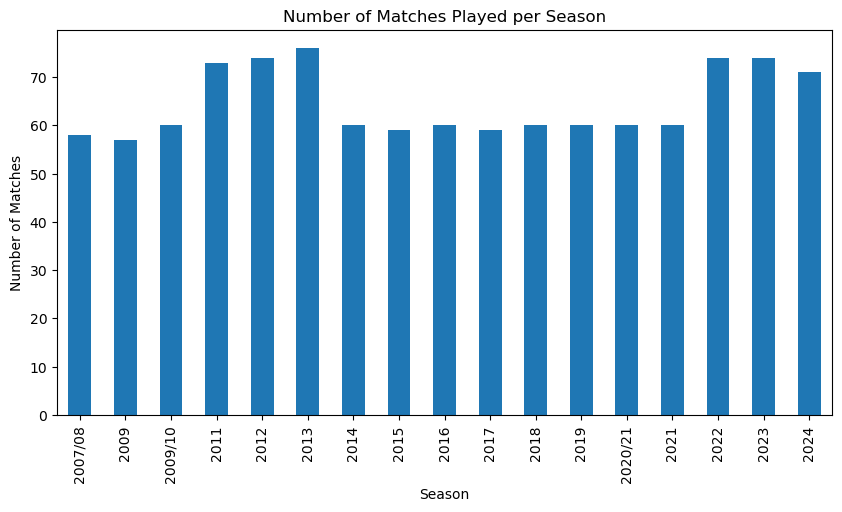

In [37]:
# Visualization
matches_per_season.plot(
    kind='bar',
    figsize=(10, 5),
    title='Number of Matches Played per Season'
)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.show()


In [38]:
# =====================================
# Team-wise Total Wins
# =====================================

team_wins = matches['winner'].value_counts()

team_wins.head(10)


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

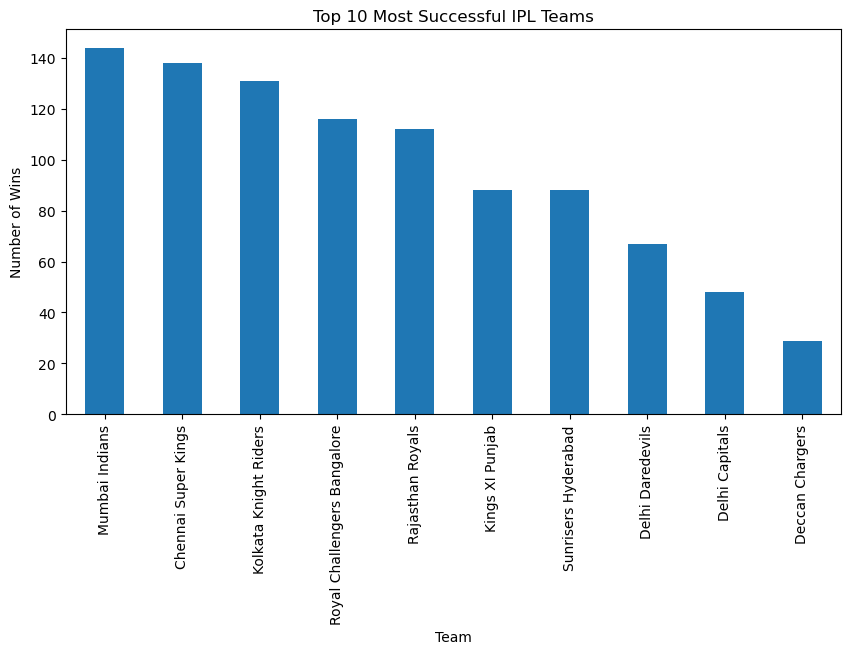

In [39]:
# Visualization
team_wins.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Most Successful IPL Teams'
)
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.show()


In [40]:
# =====================================
# Impact of Toss on Match Outcome
# =====================================

toss_match_win_count = matches['toss_winner_match_winner'].value_counts()
toss_match_win_count


toss_winner_match_winner
True     554
False    541
Name: count, dtype: int64

In [41]:
# Percentage calculation
toss_win_percentage = (
    matches['toss_winner_match_winner'].mean() * 100
)

toss_win_percentage


np.float64(50.593607305936075)

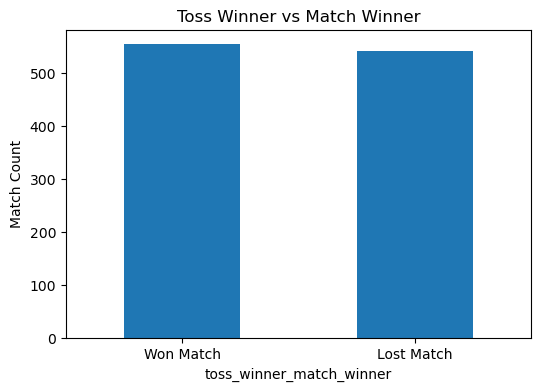

In [43]:
# Visualization
toss_match_win_count.plot(
    kind='bar',
    figsize=(6, 4),
    title='Toss Winner vs Match Winner'
)
plt.xticks([0, 1], ['Won Match','Lost Match'], rotation=0)
plt.ylabel('Match Count')
plt.show()


In [44]:
# =====================================
# Match Result Type Analysis
# =====================================

result_type_counts = matches['result'].value_counts()
result_type_counts


result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

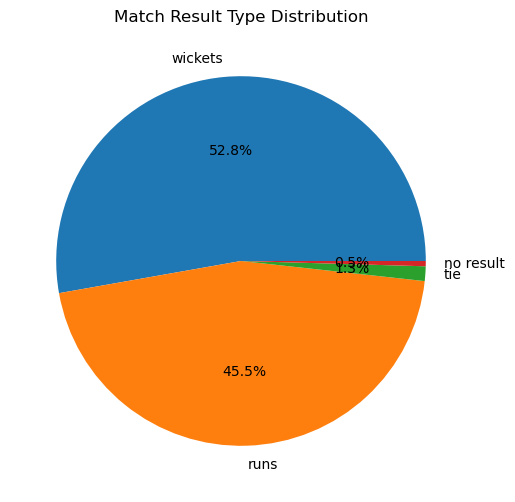

In [45]:
# Visualization
result_type_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    title='Match Result Type Distribution'
)
plt.ylabel('')
plt.show()


In [46]:
# =====================================
# No Result Matches
# =====================================

matches['is_no_result'].value_counts()


is_no_result
False    1090
True        5
Name: count, dtype: int64

In [48]:
# =====================================
# Season-wise Team Wins
# =====================================

season_team_wins = (
    matches
    .groupby(['season', 'winner'])
    .size()
    .unstack(fill_value=0)
)

season_team_wins


winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,No Result,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad
season,,,,,,,,,,,,,,,,,,,,
2007/08,9,2,0,7,0,0,10,0,6,0,7,0,0,0,13,0,0,4,0,0
2009,8,9,0,10,0,0,7,0,3,0,5,0,0,0,6,0,0,9,0,0
2009/10,9,8,0,7,0,0,4,0,7,0,11,0,0,0,6,0,0,8,0,0
2011,11,6,0,4,0,0,7,6,8,0,10,1,4,0,6,0,0,10,0,0
2012,10,4,0,11,0,0,8,0,12,0,10,0,4,0,7,0,0,8,0,0
2013,12,0,0,3,0,0,8,0,6,0,13,0,4,0,11,0,0,9,0,10
2014,10,0,0,2,0,0,12,0,11,0,7,0,0,0,7,0,0,5,0,6
2015,10,0,0,5,0,0,3,0,7,0,10,2,0,0,7,0,0,8,0,7
2016,0,0,0,7,9,0,4,0,8,0,7,0,0,0,0,0,5,9,0,11


### Key Insights
Some teams consistently outperform others across seasons

Winning the toss does not guarantee a match win

Majority of matches are won either by chasing or defending based on conditions

Match outcomes vary season by season

## Exploratory Data Analysis (EDA): Ball-Level Insights

Ball-level analysis provides the most granular view of the game, allowing us to evaluate individual player performance and in-match patterns.  
By analyzing each delivery, we can derive meaningful batting and bowling metrics that are not directly available in raw match-level data.

In this section, we focus on:
- Identifying top-performing batsmen and bowlers
- Understanding scoring patterns through runs, boundaries, and dot balls
- Calculating performance metrics such as strike rate and economy rate
- Evaluating consistency and efficiency of players

This level of analysis is critical for understanding player impact and strategic decision-making.


In [49]:
# =====================================
# Top Batsmen by Total Runs
# =====================================

top_batsmen_runs = (
    deliveries
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
)

top_batsmen_runs.head(10)


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

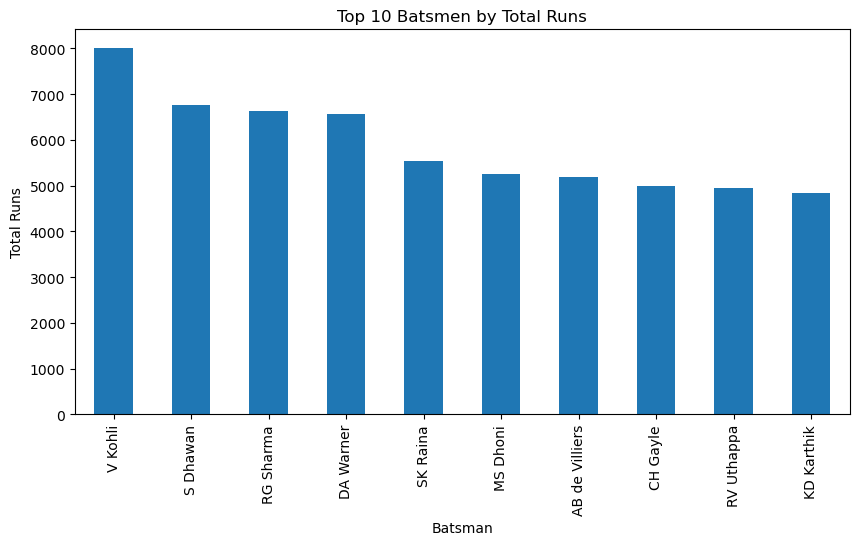

In [50]:
# Visualization
top_batsmen_runs.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Batsmen by Total Runs'
)
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.show()


In [51]:
# =====================================
# Balls Faced by Batsmen
# =====================================

balls_faced = deliveries.groupby('batter').size().sort_values(ascending=False)
balls_faced.head(10)


batter
V Kohli       6236
S Dhawan      5483
RG Sharma     5183
DA Warner     4849
SK Raina      4177
MS Dhoni      3947
RV Uthappa    3927
AM Rahane     3858
KD Karthik    3687
KL Rahul      3578
dtype: int64

In [53]:
# =====================================
# Strike Rate Calculation
# =====================================

batsman_stats = deliveries.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
)

batsman_stats['strike_rate'] = (
    batsman_stats['total_runs'] / batsman_stats['balls_faced']
) * 100

batsman_stats.sort_values('strike_rate', ascending=False).head(10)


,total_runs,balls_faced,strike_rate
batter,,,
L Wood,9,3,300.000000
B Stanlake,5,2,250.000000
J Fraser-McGurk,330,150,220.000000
R Sai Kishore,13,6,216.666667
Umar Gul,39,19,205.263158
RS Sodhi,4,2,200.000000
Shahid Afridi,81,46,176.086957
I Malhotra,7,4,175.000000
WG Jacks,230,133,172.932331


In [54]:
# =====================================
# Boundary Count by Batsmen
# =====================================

boundary_count = (
    deliveries[deliveries['is_boundary']]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)

boundary_count.head(10)


batter
V Kohli           981
S Dhawan          921
DA Warner         899
RG Sharma         880
CH Gayle          767
SK Raina          710
AB de Villiers    667
RV Uthappa        663
KD Karthik        627
MS Dhoni          615
dtype: int64

In [55]:
# =====================================
# Top Bowlers by Wickets
# =====================================

top_bowlers_wickets = (
    deliveries[deliveries['is_wicket_ball']]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
)

top_bowlers_wickets.head(10)


bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
dtype: int64

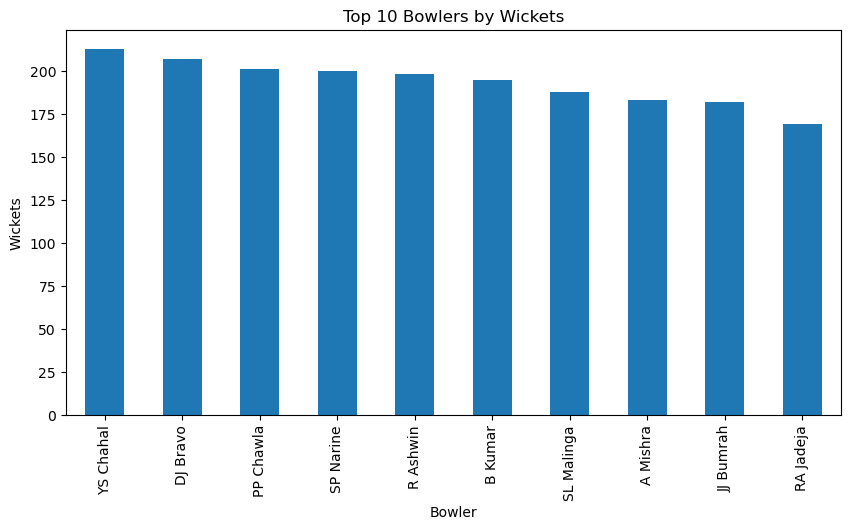

In [56]:
# Visualization
top_bowlers_wickets.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Bowlers by Wickets'
)
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.show()


In [57]:
# =====================================
# Economy Rate Calculation
# =====================================

bowler_stats = deliveries.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count')
)

bowler_stats['economy_rate'] = (
    bowler_stats['runs_conceded'] / bowler_stats['balls_bowled']
) * 6

bowler_stats.sort_values('economy_rate').head(10)


,runs_conceded,balls_bowled,economy_rate
bowler,,,
AC Gilchrist,0,1,0.000000
R Ravindra,7,12,3.500000
NB Singh,18,25,4.320000
Sachin Baby,8,10,4.800000
AM Rahane,5,6,5.000000
LA Carseldine,6,7,5.142857
SS Mundhe,6,7,5.142857
DJ Thornely,40,44,5.454545
M Manhas,42,42,6.000000


In [58]:
# =====================================
# Dot Ball Percentage
# =====================================

dot_ball_stats = deliveries.groupby('bowler').agg(
    dot_balls=('is_dot_ball', 'sum'),
    total_balls=('ball', 'count')
)

dot_ball_stats['dot_ball_percentage'] = (
    dot_ball_stats['dot_balls'] / dot_ball_stats['total_balls']
) * 100

dot_ball_stats.sort_values('dot_ball_percentage', ascending=False).head(10)


,dot_balls,total_balls,dot_ball_percentage
bowler,,,
AC Gilchrist,1,1,100.000000
SS Iyer,4,6,66.666667
SS Mundhe,4,7,57.142857
LA Carseldine,4,7,57.142857
DJ Muthuswami,44,84,52.380952
NB Singh,13,25,52.000000
MP Yadav,39,76,51.315789
JW Hastings,31,61,50.819672
Sachin Baby,5,10,50.000000


In [59]:
# =====================================
# Filter Batsmen with Minimum Balls Faced
# =====================================

batsman_stats_filtered = batsman_stats[batsman_stats['balls_faced'] >= 500]

batsman_stats_filtered.sort_values('strike_rate', ascending=False).head(10)


,total_runs,balls_faced,strike_rate
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


### Key Insights 
High run scorers are not always the fastest scorers

Strike rate adds important context to batting performance

Economy and dot-ball percentage are better bowling metrics than wickets alone

Sample size matters when evaluating player performance

## Merging Datasets & Advanced Insights

In real-world analytics projects, insights often emerge only after combining data from multiple sources.  
Merging datasets allows analysts to enrich granular data with contextual information and perform deeper analysis.

In this section, we:
- Merge match-level and ball-level datasets
- Analyze performance across seasons and match outcomes
- Derive advanced insights by combining player metrics with match context
- Visualize trends using Matplotlib and Seaborn for better storytelling

This step demonstrates the ability to move beyond isolated analysis and generate holistic, business-relevant insights.


In [60]:
# =====================================
# Merge Match-Level and Ball-Level Data
# =====================================

merged_df = deliveries.merge(
    matches[['id', 'season', 'winner', 'toss_decision']],
    left_on='match_id',
    right_on='id',
    how='left'
)

merged_df.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,is_boundary,is_dot_ball,is_single,is_double,is_triple,is_wicket_ball,id,season,winner,toss_decision
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,False,False,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,2,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,3,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,False,False,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,4,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field


In [61]:
# Check merged dataset structure
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [62]:
# =====================================
# Average Runs Per Match by Season
# =====================================

season_runs = (
    merged_df
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
)

matches_per_season = matches.groupby('season')['id'].count().reset_index()

season_summary = season_runs.merge(
    matches_per_season,
    on='season'
)

season_summary['avg_runs_per_match'] = (
    season_summary['total_runs'] / season_summary['id']
)

season_summary


,season,total_runs,id,avg_runs_per_match
0,2007/08,17937,58,309.258621
1,2009,16353,57,286.894737
2,2009/10,18883,60,314.716667
3,2011,21154,73,289.780822
4,2012,22453,74,303.418919
5,2013,22602,76,297.394737
6,2014,18931,60,315.516667
7,2015,18353,59,311.067797
8,2016,18862,60,314.366667
9,2017,18786,59,318.406780


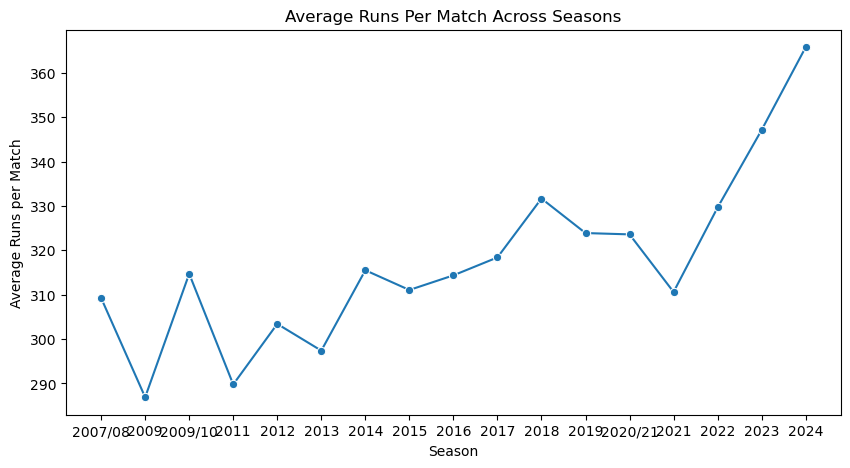

In [63]:
# Visualization using Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=season_summary,
    x='season',
    y='avg_runs_per_match',
    marker='o'
)
plt.title('Average Runs Per Match Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Runs per Match')
plt.show()


In [64]:
# =====================================
# Runs Scored Based on Toss Decision
# =====================================

toss_runs = (
    merged_df
    .groupby('toss_decision')['total_runs']
    .sum()
    .reset_index()
)

toss_runs


,toss_decision,total_runs
0,bat,120447
1,field,227309


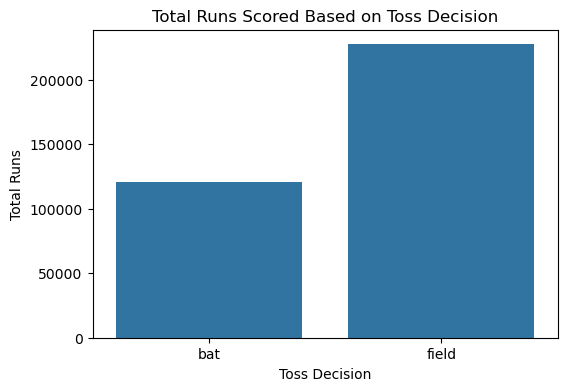

In [65]:
# Visualization
plt.figure(figsize=(6, 4))
sns.barplot(
    data=toss_runs,
    x='toss_decision',
    y='total_runs'
)
plt.title('Total Runs Scored Based on Toss Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Total Runs')
plt.show()


In [67]:
# =====================================
# Top Batsmen Runs by Season
# =====================================

top_batsmen = (
    merged_df
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

batsmen_season_runs = (
    merged_df[merged_df['batter'].isin(top_batsmen)]
    .groupby(['season', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

batsmen_season_runs.head()


,season,batter,batsman_runs
0,2007/08,RG Sharma,404
1,2007/08,S Dhawan,340
2,2007/08,SK Raina,421
3,2007/08,V Kohli,165
4,2009,DA Warner,163


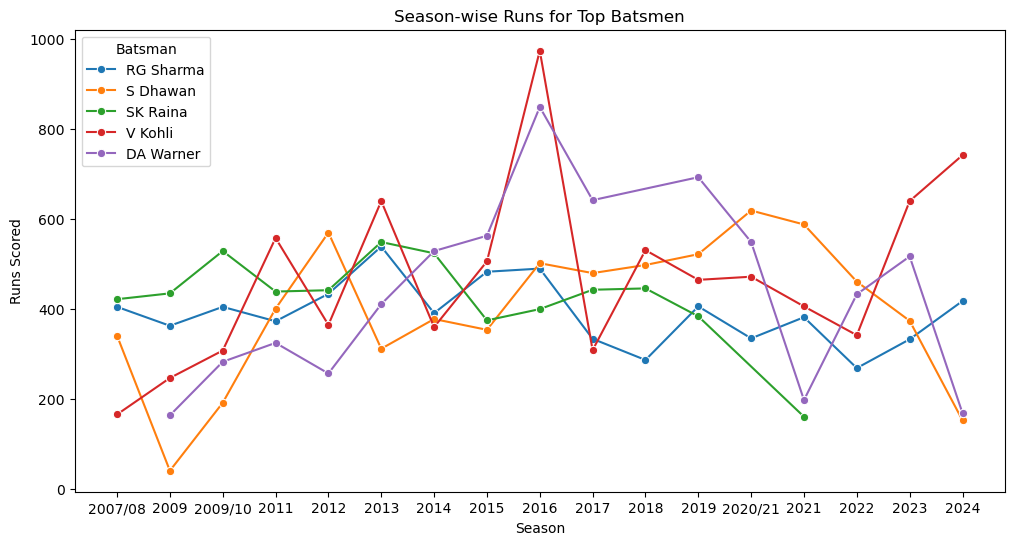

In [68]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=batsmen_season_runs,
    x='season',
    y='batsman_runs',
    hue='batter',
    marker='o'
)
plt.title('Season-wise Runs for Top Batsmen')
plt.xlabel('Season')
plt.ylabel('Runs Scored')
plt.legend(title='Batsman')
plt.show()


In [69]:
# =====================================
# Runs Scored in Winning Matches
# =====================================

winning_team_runs = (
    merged_df[merged_df['batting_team'] == merged_df['winner']]
    .groupby('winner')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

winning_team_runs.head(10)


winner
Mumbai Indians                 24187
Chennai Super Kings            23337
Kolkata Knight Riders          20978
Royal Challengers Bangalore    19256
Rajasthan Royals               18880
Sunrisers Hyderabad            14518
Kings XI Punjab                14506
Delhi Daredevils               10837
Delhi Capitals                  8294
Gujarat Titans                  4916
Name: total_runs, dtype: int64

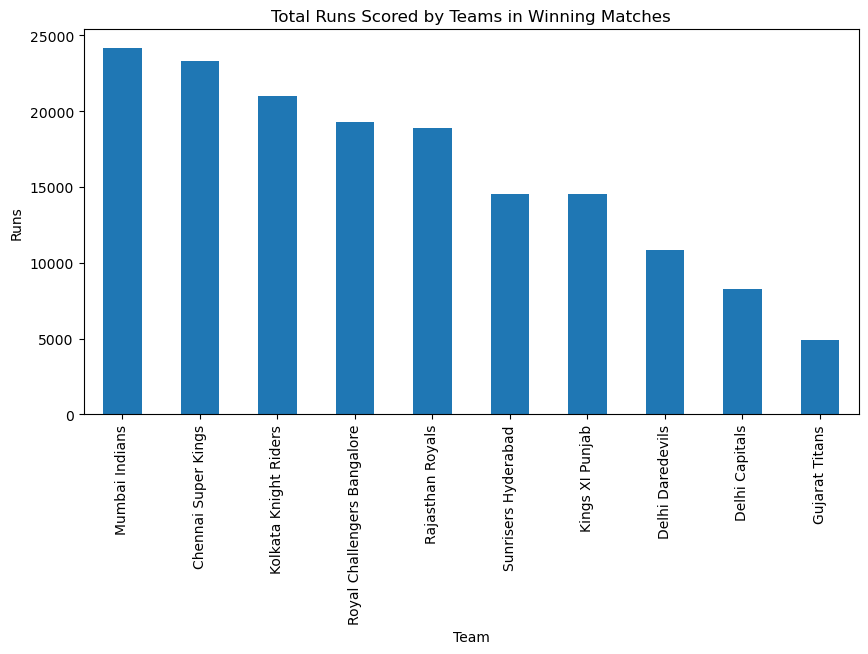

In [70]:
# Visualization
plt.figure(figsize=(10, 5))
winning_team_runs.head(10).plot(kind='bar')
plt.title('Total Runs Scored by Teams in Winning Matches')
plt.xlabel('Team')
plt.ylabel('Runs')
plt.show()


### Key Insights
Average runs per match have increased across IPL seasons

Toss decisions influence scoring patterns but do not guarantee wins

Top batsmen show distinct performance trends across seasons

Winning teams tend to have consistently higher scoring contributions

## Geographical Analysis: IPL Matches Across India

Geographical analysis helps visualize how events or activities are distributed across locations.  
In the context of IPL, mapping matches by city provides insights into regional distribution, popularity, and infrastructure concentration.

In this section, we:
- Analyze the number of IPL matches played across different cities
- Use geographical coordinates to map match locations
- Create an interactive map using the Folium library

This visualization demonstrates the ability to combine data analysis with geospatial storytelling.


In [71]:
# Install folium if required
# !pip install folium

import folium


In [72]:
# =====================================
# Matches Played Per City
# =====================================

city_matches = (
    matches
    .groupby('city')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'match_count'})
)

city_matches = city_matches[city_matches['city'] != 'Unknown']

city_matches.head()


,city,match_count
0,Abu Dhabi,37
1,Ahmedabad,36
2,Bangalore,65
3,Bengaluru,29
4,Bloemfontein,2


In [73]:
# =====================================
# City Coordinates Mapping
# =====================================

city_coordinates = {
    'Mumbai': [19.0760, 72.8777],
    'Delhi': [28.7041, 77.1025],
    'Bangalore': [12.9716, 77.5946],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Hyderabad': [17.3850, 78.4867],
    'Pune': [18.5204, 73.8567],
    'Jaipur': [26.9124, 75.7873],
    'Ahmedabad': [23.0225, 72.5714],
    'Chandigarh': [30.7333, 76.7794],
    'Indore': [22.7196, 75.8577],
    'Nagpur': [21.1458, 79.0882],
    'Dharamsala': [32.2190, 76.3234],
    'Visakhapatnam': [17.6868, 83.2185],
    'Raipur': [21.2514, 81.6296],
    'Ranchi': [23.3441, 85.3096]
}


In [74]:
# Map coordinates to city data
city_matches['coordinates'] = city_matches['city'].map(city_coordinates)

# Drop cities without coordinates
city_matches = city_matches.dropna(subset=['coordinates'])

city_matches.head()


,city,match_count,coordinates
1,Ahmedabad,36,"[23.0225, 72.5714]"
2,Bangalore,65,"[12.9716, 77.5946]"
7,Chandigarh,61,"[30.7333, 76.7794]"
8,Chennai,85,"[13.0827, 80.2707]"
10,Delhi,90,"[28.7041, 77.1025]"


In [75]:
# =====================================
# Create Base Map Centered on India
# =====================================

india_map = folium.Map(
    location=[22.5937, 78.9629],
    zoom_start=5,
    tiles='OpenStreetMap'
)


In [76]:
# =====================================
# Add Markers for Each City
# =====================================

for _, row in city_matches.iterrows():
    folium.CircleMarker(
        location=row['coordinates'],
        radius=row['match_count'] / 5,  # scale size
        popup=f"{row['city']}<br>Matches: {row['match_count']}",
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.7
    ).add_to(india_map)


In [77]:
india_map


### Key Insights
IPL matches are concentrated in major metropolitan cities

Cities like Mumbai, Bangalore, Chennai, and Delhi host the highest number of matches

Limited matches in smaller cities highlight infrastructure and audience concentration

## Final Insights & Conclusion

This project demonstrated an end-to-end data analysis workflow using IPL match and ball-by-ball data, covering data loading, cleaning, feature engineering, exploratory analysis, data merging, and visualization.

### Key Insights

- **Team Performance**
  - Certain teams have consistently outperformed others across multiple seasons, indicating strong team composition and strategy.
  - Match outcomes vary significantly by season, highlighting changes in team strength and playing conditions.

- **Toss Impact**
  - While winning the toss provides a slight advantage, it does not guarantee match victory.
  - Strategic decisions such as batting or fielding first must be evaluated in combination with pitch conditions and team strengths.

- **Batting Analysis**
  - High run scorers are not always the most efficient batsmen.
  - Strike rate provides important context when evaluating batting performance, especially for shorter formats like T20.

- **Bowling Analysis**
  - Economy rate and dot-ball percentage are stronger indicators of bowling effectiveness than wicket count alone.
  - Consistent bowlers tend to restrict scoring even when they do not take many wickets.

- **Seasonal & Trend Analysis**
  - Average runs per match have generally increased over the years, reflecting more aggressive batting approaches and evolving strategies.
  - Performance trends of top players vary across seasons, emphasizing the importance of consistency and adaptability.

- **Geographical Distribution**
  - IPL matches are heavily concentrated in major metropolitan cities.
  - This reflects infrastructure availability, audience concentration, and commercial considerations.

---

### Conclusion

Through this project, we applied Python-based data analysis techniques to a real-world sports dataset and extracted meaningful, business-relevant insights.  
The analysis highlights how raw data can be transformed into actionable information using structured workflows and analytical thinking.

This capstone project demonstrates proficiency in:
- Data cleaning and preprocessing
- Feature engineering
- Exploratory data analysis (EDA)
- Data visualization (Matplotlib, Seaborn, Folium)
- Merging datasets and deriving advanced insights

Overall, this project serves as a strong portfolio example of end-to-end data analysis using Python and reflects practical skills expected in real-world data analytics roles.
